In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Resize images to the size expected by the transformer (e.g., 72x72)
size = 72  # You can adjust the size
x_train = tf.image.resize(x_train, (size, size))
x_test = tf.image.resize(x_test, (size, size))

# Normalize pixel values

x_train = x_train / 255.0
x_test = x_test / 255.0


# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

170498071/170498071 [==============================] - 14s 0us/step


x_train shape: (50000, 32, 32, 3) - y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3) - y_test shape: (10000, 1)
Epoch 1/50
176/176 [==============================] - 104s 427ms/step - loss: 2.5467 - accuracy: 0.1534 - top-5-accuracy: 0.6403 - val_loss: 2.0450 - val_accuracy: 0.2300 - val_top-5-accuracy: 0.7610
Epoch 2/50
176/176 [==============================] - 77s 436ms/step - loss: 2.0219 - accuracy: 0.2274 - top-5-accuracy: 0.7659 - val_loss: 1.9329 - val_accuracy: 0.2704 - val_top-5-accuracy: 0.7932
Epoch 3/50
176/176 [==============================] - 77s 436ms/step - loss: 1.8922 - accuracy: 0.2766 - top-5-accuracy: 0.8174 - val_loss: 1.7316 - val_accuracy: 0.3706 - val_top-5-accuracy: 0.8750
Epoch 4/50
176/176 [==============================] - 71s 405ms/step - loss: 1.7861 - accuracy: 0.3254 - top-5-accuracy: 0.8474 - val_loss: 1.7503 - val_accuracy: 0.3694 - val_top-5-accuracy: 0.8734
Epoch 5/50
176/176 [==============================] - 77s 437ms/step - loss: 1.71

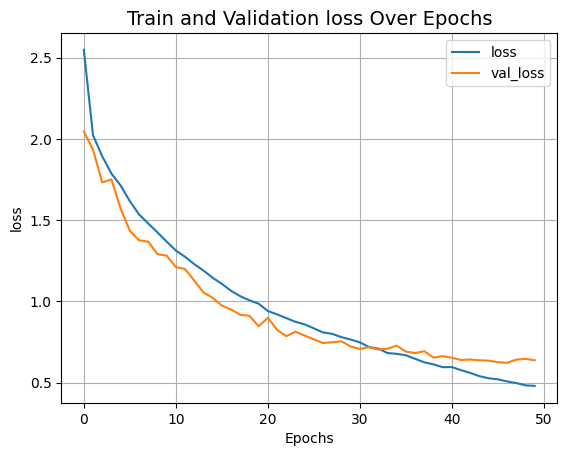

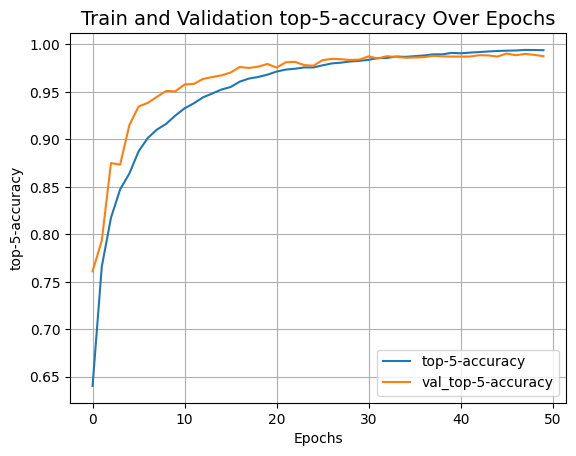

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Adjust the number of classes for CIFAR-10
num_classes = 10
input_shape = (32, 32, 3)

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(f"x_train shape: {x_train.shape} - y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

# Model configuration variables
learning_rate = 0.001
weight_decay = 0.0001
batch_size = 256  # Same as CIFAR-100
num_epochs = 50  # Increased for better training
image_size = 72  # Resize input images to this size
patch_size = 6  # Size of patches extracted from input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
transformer_layers = 8
mlp_head_units = [2048, 1024]

# Data augmentation pipeline
data_augmentation = keras.Sequential(
    [
        layers.Rescaling(1./255),  # Normalize pixel values
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Patches and PatchEncoder classes remain unchanged

def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(augmented)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    # Create a [batch_size, projection_dim] tensor.
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    # Add MLP.
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    # Classify outputs.
    logits = layers.Dense(num_classes)(features)
    # Create and return the Keras model
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

def run_experiment(model):
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        x=x_train,
        y=y_train,
        batch_size=batch_size,
        epochs=num_epochs,
        validation_split=0.1,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history

# Create and run the model
vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

plot_history("loss")
plot_history("top-5-accuracy")


In [6]:
# Comapring the DL-baed image classification algorithm in Q2 with Vision Transformer in Q4,
# the algorithm from Q2 yielded a 74.10% test accuracy fro 20 epochs while the ViT achieved
# a test accuracy of 77.67%. The ViT attains a higher score in terms of exact label prediction
# accuracy. This shows that the Vit algorithm is doing better in complex pattern if though it is
# using more data and much more ram compared to CNNs. The ViT also yielded a 98.77% top-5 accuracy
# which is a typical high accuracy when prediction fewer classes, but still indicates corret class label
# predictions.